<a href="https://colab.research.google.com/github/Akashkumar12/AI-ML/blob/main/U3_MH1_CNN_with_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification in AIML
## A Program by IIIT-H and TalentSprint

## Problem Statement

To identify and classify images as cats or dogs

## Learning Objectives

At the end of the experiment, you will be able to :

* Load and prepare images for the model using Pytorch
* Develop a CNN model and improve model performance

In [ ]:
#@title Mini-hackathon walkthrough
from IPython.display import HTML

HTML("""<video width="854" height="480" controls>
  <source src="https://cdn.talentsprint.com/aiml/aiml_2020_b14_hyd/experiment_details_backup/Pytorch_CNN_cats_and_dogs.mp4" type="video/mp4">
</video>
""")

## Dataset

The Dogs and Cats dataset is a standard computer vision dataset that involves classifying photos as either containing a dog or cat. The train folder contains ~22k images of dogs and cats. Each image in this folder has the label as part of the filename. The test folder contains ~2k images, named according to a numeric id.

## Grading = 10 Marks

## Setup Steps

In [ ]:
#@title Run this cell to download the dataset

from IPython import get_ipython
ipython = get_ipython()

notebook="U3_MH1_CNN_with_Pytorch" #name of the notebook
Answer = "This notebook is graded by mentors on the day of hackathon"
def setup():
#
   ipython.magic("sx wget http://cdn.iiith.talentsprint.com/aiml/Experiment_related_data/Cat_Dog_data_B17.zip")
   ipython.magic("sx unzip -qq Cat_Dog_data_B17.zip")
   print ("Setup completed successfully")
   return

setup()

Setup completed successfully


## Basic Pytorch packages

**torchvision:**  This package is used to load and prepare the dataset. Using this package we can perform/apply transformations on the input data.

**transforms:**  This package is  used to perform preprocessing on images and operations sequentially.

**nn:**  This package provides an easy and modular way to build and train simple or complex neural networks.

**optim:** This package is used for  implementing various optimization algorithms

In [ ]:
# Import Libraries
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
from torch import nn
import torch.nn.functional as F
from torch import optim
from torch.autograd import Variable

## **Stage 1:** Define Transformations and import data

### 1 Marks - > Compose multiple transformations with the following conditions

1. Transform image size to 128 by using Resize()

2. Convert image to Grayscale

3. Transform the image into a number using tensor

4. Normalize the tensor image with 0.5

[Hint](https://pytorch.org/vision/stable/transforms.html)

In [ ]:
image_size = (128,128)

transformations = transforms.Compose([
    transforms.Resize(image_size),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


### 1 Mark -> Load the dataset with the defined transformations

PyTorch includes a package called torchvision which is used to load and prepare the dataset. It includes two basic functions namely Dataset and DataLoader which helps in the transformation and loading of the dataset.

1. Dataset is used to read and transform a data point from the given dataset.  Note that, the data is not loaded on memory by now.

2. DataLoader is used to shuffle and batch the data. It can be used to load the data in parallel with multiprocessing workers. The Data loader reads the data and puts it into memory.



[Hint](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html)

In [ ]:
batch_size = 100

train_set = datasets.ImageFolder('/content/Cat_Dog_data/train', transform = transformations)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)


### 1 Marks -> Plot the 5 images of Cats and 5 images of Dogs

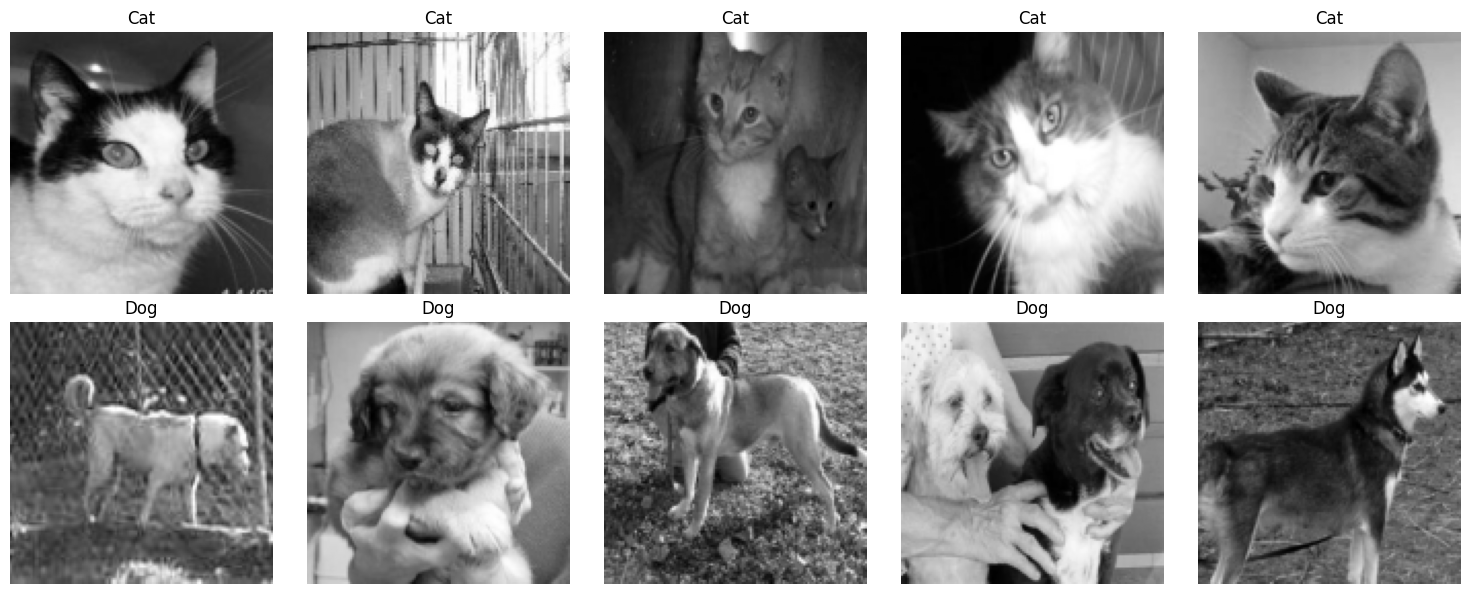

In [ ]:
# Plot 5 images of cats and 5 images of dogs
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Get some sample images from the dataset
cat_count = 0
dog_count = 0

for images, labels in train_loader:
    for i in range(len(images)):
        if labels[i] == 0 and cat_count < 5:  # Assuming 0 is cat
            axes[0, cat_count].imshow(images[i].squeeze(), cmap='gray')
            axes[0, cat_count].set_title('Cat')
            axes[0, cat_count].axis('off')
            cat_count += 1
        elif labels[i] == 1 and dog_count < 5:  # Assuming 1 is dog
            axes[1, dog_count].imshow(images[i].squeeze(), cmap='gray')
            axes[1, dog_count].set_title('Dog')
            axes[1, dog_count].axis('off')
            dog_count += 1

        if cat_count == 5 and dog_count == 5:
            break
    if cat_count == 5 and dog_count == 5:
        break

plt.tight_layout()
plt.show()


## **Stage2:** CNN Model

Neural Networks are inherited from the nn.Module class.

Define a neural network by using two functions \__init__ and forward function.

1. In the \__init__  function, perform a series of convolutions and pooling operations to detect the features. Apply a fully connected layer on top of these features. Apply LogSoftmax at the output layer to improve the performance.

2. The forward function is called on the Neural Network which takes the inputs and passes through the different layers that have been defined in the \__init__.  The output of both convolution and pooling layers is 3D whereas a fully connected layer expects a 1D vector of numbers. So flatten the output of the final pooling layer to a vector and that becomes the input to the fully connected layer.

[Hint](https://www.deeplearningwizard.com/deep_learning/practical_pytorch/pytorch_convolutional_neuralnetwork/)



### 3 Marks -> Create CNN Model


In [ ]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # Sample Convolution Layer 1
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2) # output size of the first convolutional layer is 16*128*128
        self.bn1 = nn.BatchNorm2d(16)
        self.relu1 = nn.ReLU()
        # Sample Maxpool for the Convolutional Layer 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=4, stride=4) # Maxpooling reduces the size by kernel size. After Maxpooling the output size is 16*32*32


        # Convolutional Layer 2
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=2) # output size: 32*32*32
        self.bn2 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU()
        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2) # output size: 32*16*16

        # Convolutional Layer 3
        self.cnn3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2) # output size: 64*16*16
        self.bn3 = nn.BatchNorm2d(64)
        self.relu3 = nn.ReLU()
        self.maxpool3 = nn.MaxPool2d(kernel_size=2, stride=2) # output size: 64*8*8

        # Convolutional Layer 4
        self.cnn4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1) # output size: 128*8*8
        self.bn4 = nn.BatchNorm2d(128)
        self.relu4 = nn.ReLU()
        self.maxpool4 = nn.MaxPool2d(kernel_size=2, stride=2) # output size: 128*4*4


        # Fully Connected Layer
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 2)
        self.logsoftmax = nn.LogSoftmax(dim=1)




    def forward(self, x):
        # Convolution Layer 1 and Maxpool
        out = self.cnn1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.maxpool1(out)

        # Convolution Layer 2 and Maxpool
        out = self.cnn2(out)
        out = self.bn2(out)
        out = self.relu2(out)
        out = self.maxpool2(out)

        # Convolution Layer 3 and Maxpool
        out = self.cnn3(out)
        out = self.bn3(out)
        out = self.relu3(out)
        out = self.maxpool3(out)

        # Convolution Layer 4 and Maxpool
        out = self.cnn4(out)
        out = self.bn4(out)
        out = self.relu4(out)
        out = self.maxpool4(out)


        # Flatten the output
        out = out.view(out.size(0), -1)




        # Fully Connected Layer with LogSoftmax
        out = self.fc1(out)
        out = self.relu4(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.logsoftmax(out)

        return out


### 1 Mark -> Create an instance of the model and Declare the loss function and optimizer


In [ ]:
# To run the training on GPU
print(torch.cuda.is_available())

device  =  torch.device("cuda" if torch.cuda.is_available() else "cpu")

True


In [ ]:
model = CNNModel()
model = model.to(device)
print(model)

criterion = nn.NLLLoss()  # Negative Log Likelihood Loss for LogSoftmax output

optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer with learning rate 0.001


CNNModel(
  (cnn1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (cnn2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (maxpool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu4

## **Stage 3:** Train the Model and validate it continuously to calculate the loss and accuracy for the train dataset across each epoch.

### Expected training accuracy is above 90%

### 2 Marks -> Iterate over images in the train_loader and perform the following steps.

1. First, we zero out the gradients using zero_grad()

2. We pass the data to the model. Convert the data to GPU before passing data  to the model

3. We calculate the loss using a Loss function

4. Perform Backward pass using backward() to update the weights

5. Optimize and predict by using the torch.max()

6. Calculate the accuracy of the train dataset

[Hint](https://www.deeplearningwizard.com/deep_learning/practical_pytorch/pytorch_convolutional_neuralnetwork/)

In [ ]:
# Training the model
num_epochs = 4

train_loss_list = []
train_accuracy_list = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0

    for i, (images, labels) in enumerate(train_loader):
        # Move data to GPU if available
        images = images.to(device)
        labels = labels.to(device)

        # Zero out the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Optimize
        optimizer.step()

        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        train_loss += loss.item()

        if (i+1) % 50 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

    # Calculate epoch metrics
    epoch_loss = train_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    train_loss_list.append(epoch_loss)
    train_accuracy_list.append(epoch_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%')

print('Training completed!')


Epoch [1/4], Step [50/226], Loss: 0.2518
Epoch [1/4], Step [100/226], Loss: 0.2255
Epoch [1/4], Step [150/226], Loss: 0.2110
Epoch [1/4], Step [200/226], Loss: 0.4032
Epoch [1/4], Average Loss: 0.2951, Accuracy: 87.66%
Epoch [2/4], Step [50/226], Loss: 0.2511
Epoch [2/4], Step [100/226], Loss: 0.2551
Epoch [2/4], Step [150/226], Loss: 0.2206
Epoch [2/4], Step [200/226], Loss: 0.2766
Epoch [2/4], Average Loss: 0.2454, Accuracy: 90.00%
Epoch [3/4], Step [50/226], Loss: 0.2142
Epoch [3/4], Step [100/226], Loss: 0.1110
Epoch [3/4], Step [150/226], Loss: 0.1478
Epoch [3/4], Step [200/226], Loss: 0.0637
Epoch [3/4], Average Loss: 0.2124, Accuracy: 91.24%
Epoch [4/4], Step [50/226], Loss: 0.1442
Epoch [4/4], Step [100/226], Loss: 0.2466
Epoch [4/4], Step [150/226], Loss: 0.1936
Epoch [4/4], Step [200/226], Loss: 0.1798
Epoch [4/4], Average Loss: 0.1810, Accuracy: 92.97%
Training completed!


## **Stage 4:** Testing Evaluation for CNN model

### Expected performance of test evaluation is above 90%

### 1 Marks -> Evaluate model with the given test data

1. Transform and load the test images.

2. Pass the test data through the model (network) to get the outputs

3. Get the predictions from a maximum value using torch.max

4. Compare with the actual labels and get the count of the correct labels

5. Calculate the accuracy based on the count of correct labels

In [ ]:
val_set = datasets.ImageFolder('/content/Cat_Dog_data/test',transform = transformations)

val_loader = torch.utils.data.DataLoader(val_set, batch_size=batch_size, shuffle=False)


In [ ]:
model.eval()

# Evaluate model on test data
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        # Move data to GPU if available
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Get predictions
        _, predicted = torch.max(outputs.data, 1)

        # Count correct predictions
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Calculate accuracy
test_accuracy = 100 * correct / total
print(f'Test Accuracy: {test_accuracy:.2f}%')
print(f'Correctly classified: {correct} out of {total} images')


Test Accuracy: 90.22%
Correctly classified: 1845 out of 2045 images
